# Measurement
1. Spectroscopy - goal: resonant freq 
2. separate 0/1, goal: dispersive shift
3. qubit spectroscopy - find qubit mode, power rabi & time rabi (calibrate pi gate) 
4. T1 & Ramsey (T2*) & spin echo(T2) & CPMG (T2)
automation ends
(input of automation: gates, hence need power & time)
5. find the precise qubit freq & pi gate
----- qubit cali ends-----

6. S/ T gates etc or two qubit gate


### Initialization

In [30]:
# LabOne Q:
from laboneq.simple import *

# Helpers:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_results
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import time
import laboneq
print(laboneq.__version__)

2.51.0


In [31]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.21 17:20:24.285] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.21 17:20:24.290] INFO    VERSION: laboneq 2.51.0
[2025.08.21 17:20:24.291] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.21 17:20:24.295] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.21 17:20:24.299] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.21 17:20:24.306] INFO    Configuring the device setup
[2025.08.21 17:20:24.317] INFO    The device setup is configured


## Resonator Spectroscopy

In [32]:
# frequency range of spectroscopy scan - around expected centre frequency as defined in qubit parameters
start_freq = -500.0e6 # actual_start_freq = central_freq - start_freq
stop_freq = 500.0e6
num_points = 101 # stop - start / (num_points-1)
integration_time = 1e-3
num_averages = 4 # average number = 2^n, n_max = 17


# define sweep parameter
def create_readout_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"{qubit}_res_freq",
        start=start_freq,
        stop=stop_freq,
        count=num_points,
        axis_name="Frequency [Hz]",
    )

In [33]:
# function that defines a resonator spectroscopy experiment, and takes the frequency sweep as a parameter


def res_spectroscopy_cw(freq_sweep, exp_settings):
    # Create resonator spectroscopy experiment - uses only readout drive and signal acquisition
    exp_spec = Experiment(
        uid="Resonator Spectroscopy",
        signals=[
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define experimental sequence
    # loop - average multiple measurements for each frequency - measurement in spectroscopy mode
    with exp_spec.acquire_loop_rt(
        uid="shots",
        count=pow(2, exp_settings["num_averages"]),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        with exp_spec.sweep(uid="res_freq", parameter=freq_sweep):
            # readout pulse and data acquisition
            with exp_spec.section(uid="spectroscopy"):
                # resonator signal readout
                exp_spec.acquire(
                    signal="acquire",
                    handle="res_spec",
                    length=exp_settings["integration_time"],
                )
            # relax time after readout - for signal processing and qubit relaxation to ground state
            with exp_spec.section(uid="relax", length=1e-6):
                exp_spec.reserve(signal="measure")
                exp_spec.reserve(signal="acquire")

    return exp_spec

In [34]:
# function that returns the calibration of the readout line oscillator for the experimental signals


def res_spec_calib(freq_sweep):
    exp_calibration = Calibration()
    # sets the oscillator of the experimental measure signal
    # for spectroscopy, set the sweep parameter as frequency
    measure_oscillator = Oscillator(
        "readout_acquire_osc",
        frequency=freq_sweep,
    )
    exp_calibration["measure"] = SignalCalibration(oscillator=measure_oscillator)
    exp_calibration["acquire"] = SignalCalibration(oscillator=measure_oscillator)
    return exp_calibration


# signal maps for the two different qubits - maps the logical signal of the device setup to the experimental signals of the experiment


def res_spec_map(qubit):
    signal_map = {
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map


# define the experiment with the frequency sweep relevant for qubit 0
freq_sweep = create_readout_freq_sweep("q0", start_freq, stop_freq, num_points)
exp_settings = {"integration_time": integration_time, "num_averages": num_averages}
exp_spec = res_spectroscopy_cw(freq_sweep, exp_settings)

# set signal calibration and signal map for experiment to qubit 0
exp_spec.set_calibration(res_spec_calib(freq_sweep))
exp_spec.set_signal_map(res_spec_map("q0"))

In [35]:
# compile the experiment on the open instrument session
compiled_res_spec = session.compile(exp_spec)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Resonator_Spectroscopy_Pulse_Sheet", compiled_res_spec)

[2025.08.21 17:20:24.375] INFO    Resolved modulation type of oscillator 'readout_acquire_osc' on signal 'acquire' to HARDWARE
[2025.08.21 17:20:24.377] INFO    Starting LabOne Q Compiler run...
[2025.08.21 17:20:24.395] INFO    Schedule completed. [0.015 s]
[2025.08.21 17:20:24.429] INFO    Code generation completed for all AWGs. [0.035 s]
[2025.08.21 17:20:24.429] INFO    Completed compilation step 1 of 1. [0.053 s]
[2025.08.21 17:20:24.435] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.21 17:20:24.437] INFO      Device         AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.21 17:20:24.438] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.21 17:20:24.438] INFO      device_shfqc     0         27            0           0         0  
[2025.08.21 17:20:24.439] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.21 17:20:24.440] INFO      TOTAL                      

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Resonator_Spectroscopy_Pulse_Sheet_2025-08-21-17-20-24.html

In [36]:
# run the compiled experiemnt
res_spec_results = session.run(compiled_res_spec)
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(res_spec_results, f"Results/{timestamp}_results.json")
print(f"File saved as Results/{timestamp}_results.json")

[2025.08.21 17:20:24.850] INFO    Starting near-time execution...
[2025.08.21 17:20:26.534] WARNING SHFQC/QA:dev12296: Channel 0 Output overrange count: 147
[2025.08.21 17:20:26.577] INFO    Finished near-time execution.
File saved as Results/20250821T172026_results.json


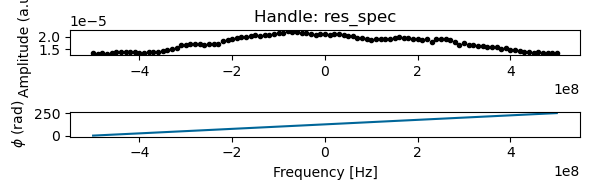

In [37]:
# plot the results
plot_results(res_spec_results, phase=True)

## Qubit Spectroscopy